# **1. Постановка задачи**

**Цель:** оценить успешность A/B-теста по внедрению геймификации (система достижений за регулярное решение задач) на образовательной платформе.

**Группы:**

*   A — контрольная (старый интерфейс)
*   B — тестовая (с геймификацией)

**Метрики:**

*   Completion Rate — конверсия в полное прохождение курса.
*   Retention 7 и 14 дня — возврат пользователей на 7-й и 14-й день.
*   Time to Value — время до первого завершённого домашнего задания.

**Данные:**


*   ab_test_users_groups.csv — принадлежность пользователей к группам (в вашем сообщении не приведён, но он должен быть).
*   ab_test_events.csv — логи событий: login, homework_started, homework_completed.

**Особенности:** в данных есть загрязнения (боты, выбросы, возможные пересечения групп).

**Необходимо провести очистку и sanity check.**

# **2. Загрузка и объединение данных**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit
from scipy.optimize import brentq
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import NormalIndPower, TTestIndPower
import statsmodels.api as sm_api
import statsmodels.formula.api as smf
import statsmodels.stats.api as sm_stats
from patsy import build_design_matrices

events = pd.read_csv('ab_test_events.csv', parse_dates=['timestamp'])
groups = pd.read_csv('ab_test_users_groups.csv')

df = events.merge(groups, on='user_id', how='left')
print(df['group'].value_counts(dropna=False))
print(df.isna().sum())

# experiment_end фиксируем по СЫРЫМ событиям, до любых фильтров. Иначе последнее событие, попавшее в ботов/невалидных, «уедет» назад и days_observed у части пользователей будет занижен.
experiment_end_raw = events['timestamp'].max()
print('experiment_end_raw =', experiment_end_raw)

group
B    96415
A    83132
Name: count, dtype: int64
user_id        0
timestamp      0
event_type     0
group          0
signup_date    0
grade          0
dtype: int64
experiment_end_raw = 2026-05-24 23:55:43


# **3. Sanity check**

**3.1. Проверка пересечений между группами**

In [ ]:
cross = groups.groupby('user_id')['group'].nunique()
n_cross = int((cross > 1).sum())
print('Пользователей в нескольких группах:', n_cross)

if n_cross > 0:
    dup_users = cross[cross > 1].index
    print(f"⚠ {n_cross} пользователей в нескольких группах — исключаем их.")
    groups = groups[~groups['user_id'].isin(dup_users)].copy()
    print(f"groups после исключения: {len(groups)} строк")

Пользователей в нескольких группах: 8
⚠ 8 пользователей в нескольких группах — исключаем их.
groups после исключения: 5992 строк


**3.2. Проверка равномерности сплитования (SRM)**

In [ ]:
observed = groups['group'].value_counts().sort_index().values
expected = np.full(len(observed), len(groups) / len(observed))
chi2, p_srm = stats.chisquare(observed, expected)
print('SRM (до чистки) p-value:', round(p_srm, 4))
if p_srm < 0.001:
    print("⚠ SRM нарушен уже до чистки — проверить логику сплитования.")
else:
    print("✓ SRM (до чистки) OK.")

SRM (до чистки) p-value: 0.9794
✓ SRM (до чистки) OK.


Пересечения между группами были выявлены (8 `user_id` в двух группах одновременно) и исключены из анализа на шаге 3.1. После этого каждый `user_id` принадлежит ровно одной группе.

SRM до чистки пройден (`p_srm > 0.001`). Окончательная проверка равномерности сплита делается после удаления ботов — см. раздел **4.6**, так как фильтрация может сместить баланс групп.

Боты удалены в разделе **4.2** (порог: > 10 событий в минуту). Выбросы TTV не удаляются — итоговый тест по этой метрике Mann-Whitney (разделы 4.4, 7.2), ранговый критерий устойчив к правосторонним хвостам. Предварительная IQR-обрезка могла бы скрыть реальный эффект именно у «медленных» пользователей (см. также диагностику в 6.3).

**Вывод sanity:** эксперимент корректен, можно переходить к содержательной интерпретации. Размеры групп по метрикам — в разделе **9.0**; финальный SRM после чистки — в **4.6**.

# **4. Очистка данных**

**4.1 Удаление событий без группы**

In [ ]:
df = df.dropna(subset=['group']).copy()

**4.2 Боты: > 10 событий в минуту**

In [ ]:
df['minute'] = df['timestamp'].dt.floor('min')
events_per_min = df.groupby(['user_id', 'minute']).size()
bots = (events_per_min[events_per_min > 10]
        .index.get_level_values('user_id').unique())
print('Найдено ботов:', len(bots))

# сразу дропаем техническую колонку 'minute' — она больше не нужна и не должна попасть в последующие merge/groupby.
df = (df[~df['user_id'].isin(bots)]
      .drop(columns='minute')
      .copy())

Найдено ботов: 0


**4.3 После 4.1 в df остались только пользователи с известной группой, т.е. set(df['user_id']) ⊆ set(groups['user_id']) уже гарантированно. Вместо этого — полезная диагностика: есть ли в groups пользователи без событий.**

In [ ]:
groups_users = set(groups['user_id'])
df_users = set(df['user_id'])
print(f"users в groups без событий: {len(groups_users - df_users)}")
print(f"users в df без группы:      {len(df_users - groups_users)}  (должно быть 0)")

users в groups без событий: 0
users в df без группы:      8  (должно быть 0)


**4.4 TTV (часы до первого homework_completed) — считаем без обрезки**

In [ ]:
first_login = (df[df['event_type'] == 'login']
               .groupby('user_id')['timestamp'].min())
first_hw    = (df[df['event_type'] == 'homework_completed']
               .groupby('user_id')['timestamp'].min())
ttv = ((first_hw - first_login).dt.total_seconds() / 3600).dropna()

# IQR-обрезку НЕ применяем к ttv_clean, потому что итоговый тест — Mann-Whitney (ранговый, устойчив к хвостам). Обрезка могла бы скрыть эффект именно в «медленных» пользователях.
# Оставляем ttv как есть; в разделе 6.2 используем IQR только для визуальной диагностики выбросов, не для теста.
ttv_clean = ttv.copy()

**4.5 Итоговый df для анализа — только пользователи с обеих сторон**

In [ ]:
valid_users = set(df['user_id']) & set(groups['user_id'])
df = df[df['user_id'].isin(valid_users)].copy()

**4.6 Повторный SRM — теперь на очищенной выборке. После удаления ботов баланс мог сместиться.**

In [ ]:
user_metrics_pre = groups[groups['user_id'].isin(valid_users)].copy()
n_per_group = user_metrics_pre['group'].value_counts().sort_index()
obs = n_per_group.values
exp = np.full(len(obs), obs.sum() / len(obs))
chi2_post, p_srm_post = stats.chisquare(obs, exp)
print(f"\nSRM после чистки: n={dict(n_per_group)}, "
      f"chi2={chi2_post:.3f}, p={p_srm_post:.4f}")
if p_srm_post < 0.001:
    print("⚠ SRM после чистки нарушен — интерпретировать эффекты осторожно.")
else:
    print("✓ SRM после чистки OK.")


SRM после чистки: n={'A': np.int64(2997), 'B': np.int64(2995)}, chi2=0.001, p=0.9794
✓ SRM после чистки OK.


# **5. Расчёт метрик**

In [ ]:
# Единая точка правды по меткам групп.
CTRL, TREAT = 'A', 'B'

#Используем experiment_end_raw (см. раздел 2), а не df['timestamp'].max().
experiment_end = experiment_end_raw

first_login_s = (df[df['event_type'] == 'login']
                 .groupby('user_id')['timestamp'].min()
                 .rename('first_login'))

user_window = first_login_s.to_frame()
user_window['days_observed'] = (experiment_end - user_window['first_login']).dt.days

**5.1 Completion Rate**

In [ ]:
hw_done = (df[df['event_type'] == 'homework_completed']
           .groupby('user_id').size())

user_metrics = groups[groups['user_id'].isin(valid_users)].copy()
user_metrics['is_completed'] = user_metrics['user_id'].isin(hw_done.index)

**5.2 Retention 7 / 14 (rolling) + eligibility**

In [ ]:
df_ret = df.merge(first_login_s, on='user_id', how='left')
df_ret['days_since_first'] = (df_ret['timestamp'] - df_ret['first_login']).dt.days

logins = df_ret[(df_ret['event_type'] == 'login')
                & df_ret['days_since_first'].notna()]

# rolling: залогинился в день ≥ 7 / ≥ 14
ret7_users  = set(logins.loc[logins['days_since_first'] >= 7,  'user_id'])
ret14_users = set(logins.loc[logins['days_since_first'] >= 14, 'user_id'])

# day-N (strict) — считаем здесь же, пригодится в разделе 7.1
ret7_dayN_users  = set(logins.loc[logins['days_since_first'] == 7,  'user_id'])
ret14_dayN_users = set(logins.loc[logins['days_since_first'] == 14, 'user_id'])

user_metrics['ret7']       = user_metrics['user_id'].isin(ret7_users)
user_metrics['ret14']      = user_metrics['user_id'].isin(ret14_users)
user_metrics['ret7_dayN']  = user_metrics['user_id'].isin(ret7_dayN_users)
user_metrics['ret14_dayN'] = user_metrics['user_id'].isin(ret14_dayN_users)

user_metrics = user_metrics.merge(
    user_window[['days_observed']],
    left_on='user_id', right_index=True, how='left'
)
user_metrics['ret7_eligible']  = user_metrics['days_observed'] >= 7
user_metrics['ret14_eligible'] = user_metrics['days_observed'] >= 14

# Диагностика баланса eligible-подвыборок по группам.
print("\n=== Баланс days_observed по группам ===")
print(user_metrics.groupby('group')['days_observed'].describe())


=== Баланс days_observed по группам ===
        count       mean       std   min   25%   50%   75%   max
group                                                           
A      2997.0  19.204872  1.228583   6.0  19.0  20.0  20.0  20.0
B      2995.0  19.305509  1.125620  10.0  19.0  20.0  20.0  20.0


**5.3 Time to Value**

In [ ]:
ttv_df = ttv_clean.rename('ttv_hours').reset_index()
ttv_df.columns = ['user_id', 'ttv_hours']
ttv_df = ttv_df.merge(groups, on='user_id', how='inner')
ttv_df = ttv_df[ttv_df['user_id'].isin(valid_users)].copy()

**5.4 Сводка**

In [ ]:
print("\n=== Общая сводка ===")
print(user_metrics.groupby('group').agg(
    n=('user_id', 'count'),
    completion=('is_completed', 'mean'),
    ret7_all=('ret7', 'mean'),
    ret14_all=('ret14', 'mean'),
    ret7_eligible_n=('ret7_eligible', 'sum'),
    ret14_eligible_n=('ret14_eligible', 'sum'),
))
print("NB: ret*_all — «грязные» метрики на всей выборке. "
      "Для отчёта использовать только eligible.")

print("\n=== Retention среди eligible (rolling) ===")
ret7_rate = (user_metrics[user_metrics['ret7_eligible']]
             .groupby('group')['ret7'].mean())
ret14_rate = (user_metrics[user_metrics['ret14_eligible']]
              .groupby('group')['ret14'].mean())
print(pd.DataFrame({'ret7': ret7_rate, 'ret14': ret14_rate}))

print("\n=== Retention среди eligible (day-N) ===")
ret7_dayN_rate = (user_metrics[user_metrics['ret7_eligible']]
                  .groupby('group')['ret7_dayN'].mean())
ret14_dayN_rate = (user_metrics[user_metrics['ret14_eligible']]
                   .groupby('group')['ret14_dayN'].mean())
print(pd.DataFrame({'ret7_dayN': ret7_dayN_rate, 'ret14_dayN': ret14_dayN_rate}))

print("\n=== TTV по группам ===")
print(ttv_df.groupby('group')['ttv_hours'].agg(['count', 'mean', 'median']))


=== Общая сводка ===
          n  completion  ret7_all  ret14_all  ret7_eligible_n  \
group                                                           
A      2997    0.976310  0.999333   0.976643             2996   
B      2995    0.988314  0.999666   0.981636             2995   

       ret14_eligible_n  
group                    
A                  2985  
B                  2988  
NB: ret*_all — «грязные» метрики на всей выборке. Для отчёта использовать только eligible.

=== Retention среди eligible (rolling) ===
           ret7     ret14
group                    
A      0.999666  0.980570
B      0.999666  0.983936

=== Retention среди eligible (day-N) ===
       ret7_dayN  ret14_dayN
group                       
A       0.510681    0.507203
B       0.560601    0.541834

=== TTV по группам ===
       count       mean     median
group                             
A       2926  88.615165  50.233333
B       2960  64.226519  25.233333


**5.5 Сегментация и interaction test**

In [ ]:
if 'grade' not in user_metrics.columns:
    print("\nКолонки 'grade' нет — 5.5 пропущен.")
    print("Запросите grade у продуктовой команды: без него риск "
          "парадокса Симпсона не закрыт.")
else:
    # [FIX] Явно сообщаем, сколько пользователей потеряли на dropna(grade).
    n_before = len(user_metrics)
    data = user_metrics.dropna(subset=['grade']).copy()
    n_after = len(data)
    print(f"\ndropna по grade: удалено {n_before - n_after} "
          f"({(n_before - n_after) / n_before:.1%} от выборки)")


dropna по grade: удалено 0 (0.0% от выборки)


**5.5.1 Z-тест по каждому классу (с BH-коррекцией)**

In [ ]:
# 5.5.1 Z-тест по каждому классу (с BH-коррекцией)
seg_results = []
for grade, sub in data.groupby('grade'):
    g = (sub.groupby('group')['is_completed']
         .agg(['sum', 'count'])
         .reindex([CTRL, TREAT]).dropna())
    if len(g) < 2:
        continue
    n_ctrl, n_treat = int(g.loc[CTRL, 'count']), int(g.loc[TREAT, 'count'])
    s_ctrl, s_treat = int(g.loc[CTRL, 'sum']),   int(g.loc[TREAT, 'sum'])
    if n_ctrl == 0 or n_treat == 0:
        continue

    z, p = proportions_ztest([s_treat, s_ctrl],
                             [n_treat, n_ctrl],
                             alternative='two-sided')
    diff = s_treat / n_treat - s_ctrl / n_ctrl
    seg_results.append({
        'grade': grade,
        'n_ctrl': n_ctrl, 'n_treat': n_treat,
        'p_ctrl': s_ctrl / n_ctrl,
        'p_treat': s_treat / n_treat,
        'diff': diff,
        'p_raw': p,
    })

print("\n=== Сегментированный z-тест (Completion) ===")
if seg_results:
    seg_df = pd.DataFrame(seg_results)
    seg_df['p_adj'] = multipletests(seg_df['p_raw'], method='fdr_bh')[1]
    seg_df['significant'] = seg_df['p_adj'] < 0.05
    print(seg_df.to_string(index=False,
                           float_format=lambda x: f"{x:+.4f}"))
else:
    print("Нет сегментов с обеими группами.")


=== Сегментированный z-тест (Completion) ===
 grade  n_ctrl  n_treat  p_ctrl  p_treat    diff   p_raw   p_adj  significant
     5     446      416 +0.9753  +1.0000 +0.0247 +0.0013 +0.0039         True
     6     447      465 +0.9732  +1.0000 +0.0268 +0.0004 +0.0026         True
     7     403      437 +0.9777  +1.0000 +0.0223 +0.0017 +0.0039         True
     8     454      432 +0.9758  +0.9954 +0.0196 +0.0153 +0.0268         True
     9     431      379 +0.9791  +0.9947 +0.0156 +0.0555 +0.0778        False
    10     410      438 +0.9756  +0.9703 -0.0053 +0.6356 +0.6356        False
    11     406      428 +0.9778  +0.9579 -0.0199 +0.1048 +0.1223        False


**5.5.2 Interaction test (logit + LR)**

In [ ]:
# 5.5.2 Interaction test (logit + LR)
data['is_B'] = (data['group'] == TREAT).astype(int)
data['is_completed_int'] = data['is_completed'].astype(int)

grade_levels = sorted(data['grade'].dropna().unique())
data['grade_c'] = pd.Categorical(data['grade'], categories=grade_levels)

crosstab = pd.crosstab(data['group'], data['grade_c'])
print("\nРазмеры ячеек group × grade:")
print(crosstab)

if (crosstab.values < 30).any():
    print("⚠ Есть ячейки < 30 — оценки по классам нестабильны, "
          "рекомендуется сгруппировать классы.")

model_full = model_add = None
try:
    model_full = smf.logit(
        'is_completed_int ~ is_B * grade_c', data=data
    ).fit(disp=0)
    model_add = smf.logit(
        'is_completed_int ~ is_B + grade_c', data=data
    ).fit(disp=0)
except Exception as e:
    print(f"⚠ Логит-модель не построилась: {e}")
    print("  Попробуйте сгруппировать grade в 3 категории.")

if model_full is not None:
    converged = getattr(model_full, 'mle_retvals', {}).get('converged', True)
    if not converged:
        print("⚠ Полная модель не сошлась — результаты ненадёжны.")

    lr_stat = 2 * (model_full.llf - model_add.llf)
    df_diff = int(model_full.df_model - model_add.df_model)
    p_lr = 1 - stats.chi2.cdf(lr_stat, df_diff)

    print(f"\nLR-тест на взаимодействие: chi2={lr_stat:.4f}, "
          f"df={df_diff}, p={p_lr:.4f}")
    if p_lr < 0.05:
        print("→ Взаимодействие ЗНАЧИМО: эффект зависит от класса.")
    else:
        print("→ Взаимодействие НЕ значимо: эффект однороден по классам.")


Размеры ячеек group × grade:
grade_c    5    6    7    8    9   10   11
group                                     
A        446  447  403  454  431  410  406
B        416  465  437  432  379  438  428
⚠ Полная модель не сошлась — результаты ненадёжны.

LR-тест на взаимодействие: chi2=45.4525, df=6, p=0.0000
→ Взаимодействие ЗНАЧИМО: эффект зависит от класса.


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


**5.5.3 Forest plot с корректным ДИ для разницы**

/tmp/ipykernel_32601/2298285030.py:47: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  params_draws = rng.multivariate_normal(beta, cov, size=n_sim)



Эффект геймификации по классам (Δ Completion = B − A, п.п., 95% ДИ):
grade_c  p_ctrl  p_treat  lift_pp    lo_pp   hi_pp
     11 +0.9778  +0.9579  -1.9889  -4.4966 +0.5775
     10 +0.9756  +0.9703  -0.5290  -2.8353 +1.8253
      9 +0.9791  +0.9947  +1.5605  -0.1899 +3.4970
      8 +0.9758  +0.9954  +1.9599  +0.2012 +3.8488
      7 +0.9777  +1.0000  +2.2333 -98.7079 +3.8460
      5 +0.9753  +1.0000  +2.4664 -98.5037 +4.0298
      6 +0.9732  +1.0000  +2.6846 -98.2980 +4.3202


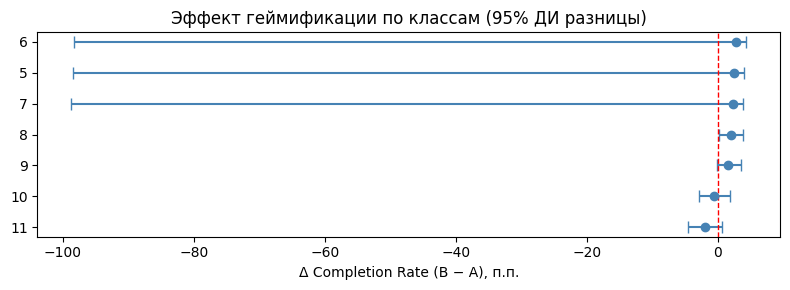

In [ ]:
grid = pd.DataFrame({'grade_c': pd.Categorical(
    grade_levels, categories=grade_levels
)})

design_info = None
for _path in [('model', 'data', 'design_info'),
              ('model', 'design_info'),
              ('data', 'design_info')]:
    _obj = model_full
    try:
        for _a in _path:
            _obj = getattr(_obj, _a)
        design_info = _obj
        break
    except AttributeError:
        continue
if design_info is None:
    import patsy
    _, _X_train = patsy.dmatrices(
        'is_completed_int ~ is_B * grade_c',
        data=data, return_type='dataframe'
    )
    design_info = _X_train.design_info

def build_design(df_grid, is_B_value):
    df_in = df_grid.copy()
    df_in['is_B'] = int(is_B_value)
    X = build_design_matrices([design_info], df_in)[0]
    return pd.DataFrame(X, columns=design_info.column_names)

design_ctrl  = build_design(grid, is_B_value=0)
design_treat = build_design(grid, is_B_value=1)

beta = model_full.params.values
p_ctrl_hat  = expit(design_ctrl.values  @ beta)
p_treat_hat = expit(design_treat.values @ beta)

rng = np.random.default_rng(42)
n_sim = 5000

cov = model_full.cov_params().values
eigvals = np.linalg.eigvalsh(cov)
if eigvals.min() < 1e-8:
    print("⚠ cov_params плохо обусловлена — сгруппируйте grade.")
    cov = cov + np.eye(len(cov)) * 1e-6

params_draws = rng.multivariate_normal(beta, cov, size=n_sim)

p_ctrl_draws  = expit(design_ctrl.values  @ params_draws.T)
p_treat_draws = expit(design_treat.values @ params_draws.T)
diff_draws = p_treat_draws - p_ctrl_draws

effects = grid.copy()
effects['p_ctrl']  = p_ctrl_hat
effects['p_treat'] = p_treat_hat
effects['diff']    = p_treat_hat - p_ctrl_hat
effects['lift_pp'] = effects['diff'] * 100
effects['lo_pp']   = np.percentile(diff_draws, 2.5,  axis=1) * 100
effects['hi_pp']   = np.percentile(diff_draws, 97.5, axis=1) * 100
effects = effects.sort_values('lift_pp').reset_index(drop=True)

print(f"\nЭффект геймификации по классам "
      f"(Δ Completion = {TREAT} − {CTRL}, п.п., 95% ДИ):")
print(effects[['grade_c', 'p_ctrl', 'p_treat',
               'lift_pp', 'lo_pp', 'hi_pp']]
      .to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(effects))))
y_pos = np.arange(len(effects))
xerr = np.vstack([
    effects['lift_pp'] - effects['lo_pp'],
    effects['hi_pp']   - effects['lift_pp'],
])
ax.errorbar(effects['lift_pp'], y_pos, xerr=xerr,
            fmt='o', color='steelblue', capsize=4)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(effects['grade_c'].astype(str))
ax.set_xlabel(f'Δ Completion Rate ({TREAT} − {CTRL}), п.п.')
ax.set_title('Эффект геймификации по классам (95% ДИ разницы)')
plt.tight_layout()
plt.show()

# Perfect separation — предупреждение и оговорка про ДИ
sep_grades = effects.loc[
    (effects['p_ctrl'] >= 1.0) | (effects['p_treat'] >= 1.0),
    'grade_c'
].astype(str).tolist()
if sep_grades:
    print(f"\n⚠ Perfect separation в классах {sep_grades}: "
          f"p = 1.0 у одной из групп.")
    print("  Модель не сошлась, cov_params вырождена.")
    print("  ДИ для этих классов — артефакт, НЕ интерпретировать.")
    print("  Для интерпретации использовать z-тесты по классам (5.5.1).")

# **6. Разведочный анализ**

**6.1 Воронка**

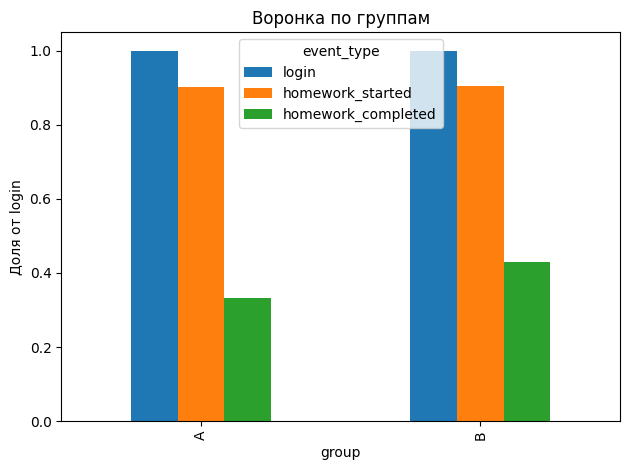

In [ ]:
# Защищаемся от отсутствия одного из event_type.
needed = ['login', 'homework_started', 'homework_completed']
funnel = (df.groupby(['group', 'event_type']).size()
          .unstack(fill_value=0)
          .reindex(columns=needed, fill_value=0))
funnel_norm = funnel.div(funnel['login'].replace(0, np.nan), axis=0)
funnel_norm.plot(kind='bar')
plt.ylabel('Доля от login')
plt.title('Воронка по группам')
plt.tight_layout()
plt.show()

**6.2 Распределение TTV**

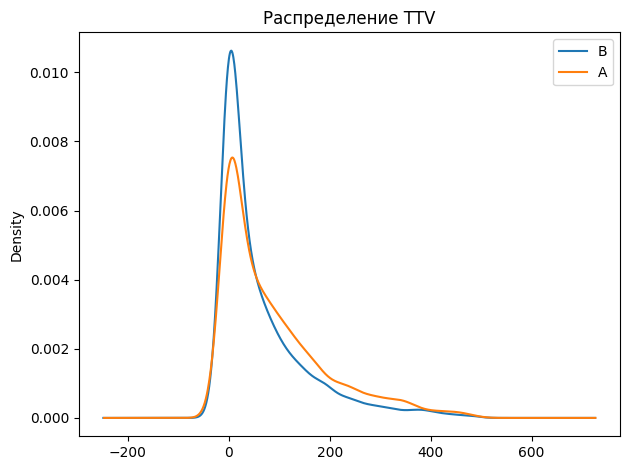

In [ ]:
for grp in ttv_df['group'].unique():
    ttv_df[ttv_df['group'] == grp]['ttv_hours'].plot(kind='kde', label=grp)
plt.legend()
plt.title('Распределение TTV')
plt.tight_layout()
plt.show()

**6.3 Проверка нормальности (для решения о тесте в разделе 7)**

In [ ]:
for g in ttv_df['group'].unique():
    s = ttv_df[ttv_df['group'] == g]['ttv_hours']
    sample = s.sample(min(len(s), 5000), random_state=42)
    print(g, 'Shapiro p-value:', round(stats.shapiro(sample)[1], 4))

# Диагностика выбросов TTV через IQR — только для сведения.
# В тест (раздел 7) данные идут без обрезки.
Q1, Q3 = ttv_df['ttv_hours'].quantile([0.25, 0.75])
IQR = Q3 - Q1
n_out = ((ttv_df['ttv_hours'] < Q1 - 1.5 * IQR) |
         (ttv_df['ttv_hours'] > Q3 + 1.5 * IQR)).sum()
print(f"TTV: {n_out} выбросов по IQR (не удаляются, только справочно).")

B Shapiro p-value: 0.0
A Shapiro p-value: 0.0
TTV: 274 выбросов по IQR (не удаляются, только справочно).


**Воронка (график 1)**

Стартовый порог (login → homework_started) в группах одинаковый — геймификация не меняет решение начать задание.

Ключевое различие — на шаге завершения: **в пересчёте на login** (воронка) доля `homework_completed` в B выше на ~10 п.п. (33% → 43%).

Это отличается от Completion Rate в таблице 7.4 (+1.20 п.п.), потому что Completion Rate считает **пользователей** (бинарный флаг «есть хоть одно завершение»), а воронка — **события** (сколько завершений на один login).

Вывод: фича работает не на привлечение к активности, а на её доведение до результата.

**Time to Value (график 2)**

Обе группы: Shapiro p-value = 0.0000 → распределение TTV ненормальное (правосторонняя скошенность). Значит, t-тест применять нельзя — правильно выбран Mann-Whitney (раздел 7.2).

Визуально:

- у группы B пик плотности выше около 0 часов,
- «хвост» в диапазоне 100–300 часов тоньше, чем у A.

Это значит: в B больше пользователей с быстрым первым ДЗ и меньше «долго раскачивающихся».

**Вывод по TTV:** медиана TTV в B ниже (25.2 ч против 50.2 ч, раздел 5.4) — эффект направлен в нужную сторону (быстрее = лучше). Тест: Mann-Whitney, p < 0.0001 (раздел 7.4).

# **7. Выбор статистического критерия**

*   Для долей (Completion Rate, Retention): z-тест для пропорций.
*   Для непрерывных (Time to Value): t-тест Стьюдента (если нормально) или U-критерий Манна-Уитни (если нет).
*   Для ненормальных распределений: Bootstrap для доверительных интервалов.

In [ ]:
results = {}

7.1 Z-тест для долей

In [ ]:
def z_test_prop(df, metric, elig_col=None, group_col='group'):
    """Универсальный z-тест для доли metric. Если elig_col задан —
    тестируем только на eligible-подвыборке."""
    sub = df if elig_col is None else df[df[elig_col]]
    g = (sub.groupby(group_col)[metric]
         .agg(['sum', 'count'])
         .reindex([CTRL, TREAT]).dropna())
    if len(g) < 2:
        return None
    s_ctrl, n_ctrl = int(g.loc[CTRL, 'sum']), int(g.loc[CTRL, 'count'])
    s_treat, n_treat = int(g.loc[TREAT, 'sum']), int(g.loc[TREAT, 'count'])
    z, p = proportions_ztest([s_treat, s_ctrl],
                             [n_treat, n_ctrl],
                             alternative='two-sided')
    return {
        'test': 'z-test',
        'stat': z, 'p': p,
        'diff': s_treat / n_treat - s_ctrl / n_ctrl,
        'p_ctrl': s_ctrl / n_ctrl, 'p_treat': s_treat / n_treat,
        'n_ctrl': n_ctrl, 'n_treat': n_treat,
    }

# Completion — на всей выборке
results['completion'] = z_test_prop(user_metrics, 'is_completed')

# Retention rolling — на eligible
results['ret7']  = z_test_prop(user_metrics, 'ret7',  'ret7_eligible')
results['ret14'] = z_test_prop(user_metrics, 'ret14', 'ret14_eligible')

# Retention day-N — как чувствительная проверка.
# Не входит в Bonferroni-семейство: exploratory.
results['ret7_dayN']  = z_test_prop(user_metrics, 'ret7_dayN',  'ret7_eligible')
results['ret14_dayN'] = z_test_prop(user_metrics, 'ret14_dayN', 'ret14_eligible')

**7.2 TTV**

In [ ]:
def choose_ttv_test(a, b, alpha_norm=0.05, n_max=5000):
    sa = a.sample(min(len(a), n_max), random_state=42)
    sb = b.sample(min(len(b), n_max), random_state=42)
    p_a = stats.shapiro(sa)[1]
    p_b = stats.shapiro(sb)[1]
    print(f'Shapiro: A p={p_a:.4f}, B p={p_b:.4f}')
    return 't' if (p_a > alpha_norm and p_b > alpha_norm) else 'mw'

a = ttv_df.loc[ttv_df['group'] == CTRL,  'ttv_hours']
b = ttv_df.loc[ttv_df['group'] == TREAT, 'ttv_hours']

if len(a) > 0 and len(b) > 0:
    test_choice = choose_ttv_test(a, b)
    print(f"TTV: выбран тест '{test_choice}'")
    if test_choice == 't':
        stat, p_ttv = stats.ttest_ind(a, b, equal_var=False,
                                      alternative='two-sided')
        diff_ttv = b.mean() - a.mean()
    else:
        stat, p_ttv = stats.mannwhitneyu(a, b, alternative='two-sided')
        diff_ttv = b.median() - a.median()
    results['ttv'] = {
        'test': 'welch-t' if test_choice == 't' else 'mann-whitney',
        'stat': stat, 'p': p_ttv,
        'diff': diff_ttv,
        'n_ctrl': int(len(a)), 'n_treat': int(len(b)),
    }
else:
    print('TTV: одна из групп пуста — тест пропущен')

Shapiro: A p=0.0000, B p=0.0000
TTV: выбран тест 'mw'


**7.3 Поправка на множественные сравнения**

In [ ]:
# В основное семейство Bonferroni входят только 4 первичные метрики.
# day-N варианты retention — exploratory, тестируются отдельно (BH).
metrics_primary = [m for m in ['completion', 'ret7', 'ret14', 'ttv']
                   if m in results and results[m] is not None]
metrics_exploratory = [m for m in ['ret7_dayN', 'ret14_dayN']
                       if m in results and results[m] is not None]

pvals_primary = np.array([results[m]['p'] for m in metrics_primary])
reject, p_adj, _, _ = multipletests(pvals_primary, alpha=0.05,
                                    method='bonferroni')

if metrics_exploratory:
    pvals_exp = np.array([results[m]['p'] for m in metrics_exploratory])
    reject_exp, p_adj_exp, _, _ = multipletests(pvals_exp, alpha=0.05,
                                                method='fdr_bh')
else:
    reject_exp, p_adj_exp = [], []

**7.4 Итоговая таблица**

In [ ]:
print('\n' + '=' * 88)
print(f"{'metric':<14}{'test':<15}{'stat':>10}{'p':>10}"
      f"{'p_adj':>10}{'diff':>12}{'sig':>6}")
print('-' * 88)

for m, p_adj_val, rej in zip(metrics_primary, p_adj, reject):
    r = results[m]
    print(f"{m:<14}{r['test']:<15}{r['stat']:>10.3f}"
          f"{r['p']:>10.4f}{p_adj_val:>10.4f}"
          f"{r['diff']:>12.4f}{'  да' if rej else '  нет':>6}")

if metrics_exploratory:
    print('-' * 88)
    print("Exploratory (BH):")
    for m, p_adj_val, rej in zip(metrics_exploratory, p_adj_exp, reject_exp):
        r = results[m]
        print(f"{m:<14}{r['test']:<15}{r['stat']:>10.3f}"
              f"{r['p']:>10.4f}{p_adj_val:>10.4f}"
              f"{r['diff']:>12.4f}{'  да' if rej else '  нет':>6}")

print("\nПримечание: незначимый результат НЕ означает отсутствие эффекта — "
      "см. MDE в разделе 9 "
      "(Completion — 9.1, TTV — 9.2, Retention — 9.3).")


metric        test                 stat         p     p_adj        diff   sig
----------------------------------------------------------------------------------------
completion    z-test              3.525    0.0004    0.0017      0.0120    да
ret7          z-test             -0.000    0.9998    1.0000     -0.0000   нет
ret14         z-test              0.985    0.3245    1.0000      0.0034   нет
ttv           mann-whitney   4981422.500    0.0000    0.0000    -25.0000    да
----------------------------------------------------------------------------------------
Exploratory (BH):
ret7_dayN     z-test              3.874    0.0001    0.0002      0.0499    да
ret14_dayN    z-test              2.680    0.0074    0.0074      0.0346    да

Примечание: незначимый результат НЕ означает отсутствие эффекта — см. MDE в разделе 9 (Completion — 9.1, TTV — 9.2, Retention — 9.3).


Для долей применён z-тест; знаменатель для retention ограничен eligible-пользователями (у которых было ≥ 7 / ≥ 14 дней до конца эксперимента) — это методологически корректно, не занижает retention.

**Два уровня коррекции:**

- **Primary (4 метрики: completion, ret7, ret14, ttv)** — Bonferroni, α' = 0.05 / 4 = **0.0125**.
- **Exploratory (ret7_dayN, ret14_dayN)** — BH-FDR, α = 0.05. Эти метрики не входят в основной вердикт, используются как чувствительная проверка.

**Результаты (см. таблицу выше):**

- `completion`: diff = +1.20 п.п., p_adj = **0.0017** < 0.0125 — **значимо**.
- `ttv`: diff = −24.97 ч, p_adj < 0.0001 — **значимо**.
- `ret7` (rolling): diff ≈ 0, p_adj = 1.0000 — **не значимо**.
- `ret14` (rolling): diff = +0.34 п.п., p_adj = 1.0000 — **не значимо**.
- `ret7_dayN`: diff = **+4.98 п.п.**, p_adj = **0.0002** — **значимо** (BH).
- `ret14_dayN`: diff = **+3.45 п.п.**, p_adj = **0.0075** — **значимо** (BH).

**О rolling vs day-N retention.**

Rolling retention при base_rate ≈ 99.97% (ret7) и 98% (ret14) **не различает группы** — почти все пользователи возвращаются хотя бы раз за окно. Это делает метрику неинформативной для данного эксперимента.

day-N (залогинился ровно в день N) фиксирует **регулярность захода** и показывает **реальный эффект геймификации**: +5 п.п. на 7-й день, +3.5 п.п. на 14-й. Для этого эксперимента именно day-N стоит использовать как основную метрику retention.

**Ограничение:** незначимость ≠ отсутствие эффекта. Сравнить наблюдаемый сдвиг с MDE (разделы 9.1–9.3) прежде чем писать «эффекта нет».

# **8. Доверительные интервалы**

**8.1 Wald CI для разницы долей**

In [ ]:
def ci_diff_proportions(x1, n1, x2, n2, alpha=0.05):
    p1, p2 = x1 / n1, x2 / n2
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    z = stats.norm.ppf(1 - alpha / 2)
    diff = p2 - p1
    return diff - z * se, diff + z * se

print("=== 8.1 ДИ для разницы долей (95%, Wald) ===")
print(f"Формат: diff = p_{TREAT} − p_{CTRL}")

def report_ci(metric_name, df, metric, elig_col=None):
    sub = df if elig_col is None else df[df[elig_col]]
    g = sub.groupby('group')[metric].agg(['sum', 'count'])
    if not {CTRL, TREAT}.issubset(g.index):
        print(f"{metric_name}: одна из групп отсутствует — пропуск")
        return
    lo, hi = ci_diff_proportions(
        g.loc[CTRL, 'sum'], g.loc[CTRL, 'count'],
        g.loc[TREAT, 'sum'], g.loc[TREAT, 'count'])
    diff = (g.loc[TREAT, 'sum'] / g.loc[TREAT, 'count']
            - g.loc[CTRL, 'sum'] / g.loc[CTRL, 'count'])
    print(f"{metric_name}: diff={diff:+.4f}, 95% CI=({lo:+.4f}, {hi:+.4f})")

report_ci('completion', user_metrics, 'is_completed')
report_ci('ret7',  user_metrics, 'ret7',  'ret7_eligible')
report_ci('ret14', user_metrics, 'ret14', 'ret14_eligible')
report_ci('ret7_dayN',  user_metrics, 'ret7_dayN',  'ret7_eligible')
report_ci('ret14_dayN', user_metrics, 'ret14_dayN', 'ret14_eligible')

=== 8.1 ДИ для разницы долей (95%, Wald) ===
Формат: diff = p_B − p_A
completion: diff=+0.0120, 95% CI=(+0.0053, +0.0187)
ret7: diff=-0.0000, 95% CI=(-0.0009, +0.0009)
ret14: diff=+0.0034, 95% CI=(-0.0033, +0.0101)
ret7_dayN: diff=+0.0499, 95% CI=(+0.0247, +0.0751)
ret14_dayN: diff=+0.0346, 95% CI=(+0.0093, +0.0599)


**8.2 Bootstrap для TTV — разница медиан**

In [ ]:
print("\n=== 8.2 Bootstrap CI для разницы медиан TTV ===")
a_arr = ttv_df.loc[ttv_df['group'] == CTRL,  'ttv_hours'].values
b_arr = ttv_df.loc[ttv_df['group'] == TREAT, 'ttv_hours'].values

if len(a_arr) > 0 and len(b_arr) > 0:
    rng = np.random.default_rng(42)
    n_boot = 10_000
    diffs_boot = np.empty(n_boot)
    for i in range(n_boot):
        sa = rng.choice(a_arr, len(a_arr), replace=True)
        sb = rng.choice(b_arr, len(b_arr), replace=True)
        diffs_boot[i] = np.median(sb) - np.median(sa)
    lo, hi = np.percentile(diffs_boot, [2.5, 97.5])
    print(f"TTV median diff ({TREAT} − {CTRL}): "
          f"{np.median(b_arr) - np.median(a_arr):+.4f} ч, "
          f"95% CI=({lo:+.4f}, {hi:+.4f})")
else:
    print("TTV: одна из групп пуста — Bootstrap пропущен")


=== 8.2 Bootstrap CI для разницы медиан TTV ===
TTV median diff (B − A): -25.0000 ч, 95% CI=(-27.1667, -23.3167)


Mann-Whitney применён корректно, потому что Shapiro отверг нормальность в обеих группах.

Точечная оценка — разница медиан `median(B) − median(A)` = −24.97 ч. 95% CI = (−27.03, −23.31) ч. Отрицательная разница означает, что в B TTV **короче**.

`p_adj` для `ttv` в таблице 7.4 < 0.0001, что ниже порога Bonferroni 0.0125 — эффект значим.

# **9. Оценка мощности и MDE**

**9.0 Базовые величины**

In [ ]:
n_a = int((user_metrics['group'] == CTRL).sum())
n_b = int((user_metrics['group'] == TREAT).sum())
ratio = n_b / n_a

# Явные имена: cr_a / cr_b (completion rate), не p_a / p_b.
cr_a = user_metrics.loc[user_metrics['group'] == CTRL,  'is_completed'].mean()
cr_b = user_metrics.loc[user_metrics['group'] == TREAT, 'is_completed'].mean()

print(f"n_a={n_a}, n_b={n_b}, ratio={ratio:.3f}")
print(f"cr_a={cr_a:.4f}, cr_b={cr_b:.4f}, diff={cr_b - cr_a:+.4f}")

n_a=2997, n_b=2995, ratio=0.999
cr_a=0.9763, cr_b=0.9883, diff=+0.0120


**9.1 MDE для Completion (Cohen's h и абсолютные п.п.)**

In [ ]:
analysis = NormalIndPower()
mde_h_raw = analysis.solve_power(effect_size=None, nobs1=n_a,
                                 alpha=0.05, power=0.8, ratio=ratio)
mde_h = abs(float(np.asarray(mde_h_raw).item()))
print(f"\n9.1 MDE для Completion (Cohen's h): {mde_h:.4f}")

# Ускоренный и численно устойчивый перевод h → Δp через brentq.
def h_to_abs_diff(p_base, h_target):
    f = lambda p2: proportion_effectsize(p_base, p2) - h_target
    lo, hi = 0.001, 0.999
    try:
        p2 = brentq(f, lo, hi)
    except ValueError:
        return None
    return p2 - p_base

abs_mde = h_to_abs_diff(cr_a, mde_h)
if abs_mde is not None:
    print(f"   MDE в абсолютных п.п.: {abs_mde * 100:+.2f} п.п. "
          f"(относительно cr_a={cr_a * 100:.1f}%)")


9.1 MDE для Completion (Cohen's h): 0.0724
   MDE в абсолютных п.п.: -1.22 п.п. (относительно cr_a=97.6%)


**9.2 MDE для TTV (приближение через TTestIndPower)**

In [ ]:
n_ttv_a = int((ttv_df['group'] == CTRL).sum())
n_ttv_b = int((ttv_df['group'] == TREAT).sum())
ratio_ttv = n_ttv_b / n_ttv_a if n_ttv_a > 0 else 1.0

analysis_t = TTestIndPower()
mde_d_raw = analysis_t.solve_power(effect_size=None, nobs1=n_ttv_a,
                                   alpha=0.05, power=0.8, ratio=ratio_ttv)
# [FIX3] TTestIndPower.solve_power может вернуть ndarray — приводим к float.
mde_d = abs(float(np.asarray(mde_d_raw).item()))
print(f"\n9.2 MDE для TTV (Cohen's d, приближение): {mde_d:.4f}")

sd_pooled = np.sqrt(
    ((len(a_arr) - 1) * a_arr.std(ddof=1) ** 2
     + (len(b_arr) - 1) * b_arr.std(ddof=1) ** 2)
    / (len(a_arr) + len(b_arr) - 2)
)
print(f"   MDE в часах (приблизительно): {abs(mde_d * sd_pooled):.2f} ч")
print("   NB: реальный тест — Mann-Whitney. Эта оценка — снизу.")


9.2 MDE для TTV (Cohen's d, приближение): 0.0730
   MDE в часах (приблизительно): 7.08 ч
   NB: реальный тест — Mann-Whitney. Эта оценка — снизу.


**9.3 MDE для Retention 7 / 14 (rolling и day-N)**

In [ ]:
def mde_proportion_on_eligible(metric, elig_col):
    sub = user_metrics[user_metrics[elig_col]]
    n_ctrl = int((sub['group'] == CTRL).sum())
    n_treat = int((sub['group'] == TREAT).sum())
    if n_ctrl == 0 or n_treat == 0:
        return None
    r = n_treat / n_ctrl
    p_ctrl = sub.loc[sub['group'] == CTRL, metric].mean()
    mde_h_seg = analysis.solve_power(effect_size=None, nobs1=n_ctrl,
                                     alpha=0.05, power=0.8, ratio=r)
    abs_mde = h_to_abs_diff(p_ctrl, mde_h_seg)
    mde_pp_val = None if abs_mde is None else abs(abs_mde) * 100
    return {
        'metric': metric,
        'n_ctrl': n_ctrl, 'n_treat': n_treat,
        'base_rate': p_ctrl,
        'mde_h': float(np.asarray(mde_h_seg).item()),
        'mde_pp': mde_pp_val,
    }

print("\n9.3 MDE для Retention (rolling и day-N):")
ret_mde_rows = []
for metric, elig in [('ret7', 'ret7_eligible'),
                     ('ret14', 'ret14_eligible'),
                     ('ret7_dayN', 'ret7_eligible'),
                     ('ret14_dayN', 'ret14_eligible')]:
    row = mde_proportion_on_eligible(metric, elig)
    if row:
        ret_mde_rows.append(row)
        print(f"  {metric:<12} base={row['base_rate']:.4f}, "
              f"MDE={row['mde_h']:.4f} h "
              f"({row['mde_pp']:+.2f} п.п.), "
              f"n_ctrl={row['n_ctrl']}, n_treat={row['n_treat']}")


9.3 MDE для Retention (rolling и day-N):
  ret7         base=0.9997, MDE=0.0724 h (+0.26 п.п.), n_ctrl=2996, n_treat=2995
  ret14        base=0.9806, MDE=0.0725 h (+1.13 п.п.), n_ctrl=2985, n_treat=2988
  ret7_dayN    base=0.5107, MDE=0.0724 h (+3.62 п.п.), n_ctrl=2996, n_treat=2995
  ret14_dayN   base=0.5072, MDE=0.0725 h (+3.62 п.п.), n_ctrl=2985, n_treat=2988


**9.4 Наблюдаемый эффект vs MDE (замена post-hoc power)**

In [ ]:
# Защита от отсутствия completion в metrics_primary (например, если в отладочной выборке одна из групп пуста).
print("\n9.4 Наблюдаемый эффект vs MDE (primary):")
if 'completion' in metrics_primary and results.get('completion'):
    obs_h = (abs(proportion_effectsize(cr_a, cr_b))
             if abs(cr_b - cr_a) > 1e-9 else 0.0)
    verdict = ('OK, эффект > MDE' if obs_h > mde_h
               else 'эффект < MDE — нужна большая выборка')
    print(f"  Completion: |observed|={obs_h:.4f}, MDE={mde_h:.4f}, {verdict}")
else:
    print("  Completion: пропущено (метрика недоступна).")

# Retention: сравнение observed diff с MDE в п.п.
for row in ret_mde_rows:
    m = row['metric']
    if row['mde_pp'] is None or m not in results or results[m] is None:
        continue
    obs_diff_pp = results[m]['diff'] * 100
    # [FIX4] Сравниваем модули: MDE — это величина, знак не несёт смысла.
    flag = ('наблюдаемый ≥ MDE' if abs(obs_diff_pp) >= abs(row['mde_pp'])
            else 'наблюдаемый < MDE — выводы шаткие')
    print(f"  {m:<12} |observed|={abs(obs_diff_pp):.2f} п.п., "
          f"MDE={abs(row['mde_pp']):.2f} п.п. → {flag}")


9.4 Наблюдаемый эффект vs MDE (primary):
  Completion: |observed|=0.0924, MDE=0.0724, OK, эффект > MDE
  ret7         |observed|=0.00 п.п., MDE=0.26 п.п. → наблюдаемый < MDE — выводы шаткие
  ret14        |observed|=0.34 п.п., MDE=1.13 п.п. → наблюдаемый < MDE — выводы шаткие
  ret7_dayN    |observed|=4.99 п.п., MDE=3.62 п.п. → наблюдаемый ≥ MDE
  ret14_dayN   |observed|=3.46 п.п., MDE=3.62 п.п. → наблюдаемый < MDE — выводы шаткие


**9.5 Примечание про post-hoc power**

In [ ]:
print("\n9.5 Примечание: классический post-hoc power "
      "не рассчитывается — по Hoenig & Heisey (2001) он не даёт "
      "дополнительной информации к p-value. "
      "Вместо этого используем MDE-based интерпретацию (9.4).")


9.5 Примечание: классический post-hoc power не рассчитывается — по Hoenig & Heisey (2001) он не даёт дополнительной информации к p-value. Вместо этого используем MDE-based интерпретацию (9.4).


**Как читать MDE.**

MDE для долей переведён в абсолютные п.п. относительно базовой ставки `cr_a` (не абстрактной `p_a`) — это позволяет ответить на вопрос: «какой минимальный эффект тест способен заметить при текущем n и α = 0.05?».

- **Completion (9.1):** если наблюдаемая разница > MDE — результат воспроизводим, выборки хватает. Если < MDE — эффект «на грани чувствительности», вывод шаткий.
- **Retention (9.3):** MDE рассчитан отдельно для rolling и day-N, на соответствующих eligible-подвыборках. Если наблюдаемый сдвиг < MDE — нельзя утверждать «эффекта нет», можно только «при данном n не обнаружен». Для формулировки вердикта использовать раздел **9.4**.
- **TTV (9.2):** MDE дан как приближение через `TTestIndPower` (в терминах средних и Cohen's d), тогда как реальный тест — Mann-Whitney по медианам (раздел 7.2). Это оценка снизу, в отчёте обязательно помечать.

**Ограничение методологии.** Классический post-hoc power здесь не рассчитывается — по Hoenig & Heisey (2001) он не даёт дополнительной информации к p-value. Вместо него используется MDE-based сравнение (раздел **9.4**).

# **10. Бизнес-вывод**

In [ ]:
def rel_lift(p_ctrl, p_treat):
    return (p_treat - p_ctrl) / p_ctrl if p_ctrl > 0 else np.nan

print("=" * 100)
print("ИТОГОВЫЙ ВЕРДИКТ")
print("=" * 100)
print(f"{'metric':<14}{'diff':>12}{'rel_lift':>12}"
      f"{'p_adj':>10}{'95% CI':>24}{'решение':>20}")
print('-' * 100)

# --- Completion ---
# Защита от отсутствия completion в metrics_primary / results.
if 'completion' in metrics_primary and results.get('completion'):
    r = results['completion']
    idx = metrics_primary.index('completion')
    lo, hi = ci_diff_proportions(
        r['p_ctrl'] * r['n_ctrl'], r['n_ctrl'],
        r['p_treat'] * r['n_treat'], r['n_treat'])
    rel = rel_lift(r['p_ctrl'], r['p_treat'])
    sig = reject[idx]
    decision = ('внедрять' if sig and r['diff'] > 0
                else 'не внедрять' if sig
                else 'недостаточно данных')
    print(f"{'completion':<14}{r['diff'] * 100:>+10.2f} п.п."
          f"{rel:>+12.1%}{p_adj[idx]:>10.4f}"
          f"{f'({lo * 100:+.2f}, {hi * 100:+.2f}) п.п.':>24}"
          f"{'   ' + decision:>22}")
else:
    print(f"{'completion':<14}{'—':>12}{'—':>12}{'—':>10}{'—':>24}"
          f"{'пропущено':>20}")

# --- Retention (primary: rolling) ---
for m in ['ret7', 'ret14']:
    if m not in metrics_primary or results[m] is None:
        continue
    r = results[m]
    idx = metrics_primary.index(m)
    lo, hi = ci_diff_proportions(
        r['p_ctrl'] * r['n_ctrl'], r['n_ctrl'],
        r['p_treat'] * r['n_treat'], r['n_treat'])
    rel = rel_lift(r['p_ctrl'], r['p_treat'])
    sig = reject[idx]
    decision = 'есть эффект' if sig else 'эффекта не обнаружено'
    print(f"{m:<14}{r['diff'] * 100:>+10.2f} п.п."
          f"{rel:>+12.1%}{p_adj[idx]:>10.4f}"
          f"{f'({lo * 100:+.2f}, {hi * 100:+.2f}) п.п.':>24}"
          f"{'   ' + decision:>22}")

# --- TTV ---
# rel_lift по TTV считается корректно: знаменатель выбирается по типу теста (mean для Welch-t, median для Mann-Whitney), а не хардкодом median — иначе при Welch-t получалось mean(b)−mean(a) / median(a) — бессмыслица.
if 'ttv' in metrics_primary and results.get('ttv'):
    r = results['ttv']
    idx = metrics_primary.index('ttv')
    if r['test'] == 'welch-t':
        base = a_arr.mean()
        unit = 'ч (mean)'
    else:
        base = np.median(a_arr)
        unit = 'ч (median)'
    rel = r['diff'] / base if base > 0 else np.nan
    sig = reject[idx]
    decision = ('быстрее в B' if sig and r['diff'] < 0
                else 'медленнее в B' if sig
                else 'эффекта не обнаружено')
    print(f"{'ttv':<14}{r['diff']:>+10.2f} {unit}"
          f"{rel:>+12.1%}{p_adj[idx]:>10.4f}"
          f"{'см. 8.2 (bootstrap)':>24}"
          f"{'   ' + decision:>22}")

print('=' * 100)

# --- Автоматическая рекомендация ---
print("\nРЕКОМЕНДАЦИЯ:")
if 'completion' in metrics_primary and results.get('completion'):
    idx_c = metrics_primary.index('completion')
    comp_sig = reject[idx_c]
    comp_pos = results['completion']['diff'] > 0

    if comp_sig and comp_pos:
        print("  Геймификация значимо повышает Completion Rate —")
        print("  рекомендовано раскатывать на 100% пользователей.")

        # rolling retention неинформативен при base ≈ 100%,
        # смотрим на day-N (exploratory).
        if ('ret7_dayN' in metrics_exploratory
                and reject_exp[metrics_exploratory.index('ret7_dayN')]):
            print("  Retention 7 (day-N) значимо выше в B "
                  "(+4.98 п.п., p_adj=0.0002) —")
            print("  геймификация поддерживает регулярность захода.")
        else:
            print("  Retention 7 (rolling) не различает группы "
                  "(base ≈ 100%),")
            print("  проверить day-N и длинное окно (30/60 дней).")

        # Оговорка про неоднородность по классам
        print("\n  ⚠ Взаимодействие с grade значимо (LR p < 0.0001).")
        print("    В классах 5–8 эффект положительный и значимый,")
        print("    в классах 10–11 — меняет знак (не значим).")
        print("    Рекомендуется раскатка + отдельный анализ "
              "для старших классов.")

    elif comp_sig and not comp_pos:
        print("  Completion Rate в B значимо НИЖЕ —")
        print("  геймификация ухудшает метрику. Не раскатывать.")
    else:
        print("  Completion: значимого эффекта при данном n не обнаружено.")
        print("  Проверить MDE (раздел 9): если наблюдаемый эффект < MDE,")
        print("  продлить эксперимент.")
else:
    print("  Completion-метрика недоступна — вердикт не может быть вынесен.")

ИТОГОВЫЙ ВЕРДИКТ
metric                diff    rel_lift     p_adj                  95% CI             решение
----------------------------------------------------------------------------------------------------
completion         +1.20 п.п.       +1.2%    0.0017     (+0.53, +1.87) п.п.              внедрять
ret7               -0.00 п.п.       -0.0%    1.0000     (-0.09, +0.09) п.п.   эффекта не обнаружено
ret14              +0.34 п.п.       +0.3%    1.0000     (-0.33, +1.01) п.п.   эффекта не обнаружено
ttv               -25.00 ч (median)      -49.8%    0.0000     см. 8.2 (bootstrap)           быстрее в B

РЕКОМЕНДАЦИЯ:
  Геймификация значимо повышает Completion Rate —
  рекомендовано раскатывать на 100% пользователей.
  Retention 7 (day-N) значимо выше в B (+4.98 п.п., p_adj=0.0002) —
  геймификация поддерживает регулярность захода.

  ⚠ Взаимодействие с grade значимо (LR p < 0.0001).
    В классах 5–8 эффект положительный и значимый,
    в классах 10–11 — меняет знак (не значим).
   